# Preparación del proyecto

In [1]:
!pip install rdflib owlrl scikit-fuzzy frozendict schema
!pip install --no-deps experta==1.9.4

In [2]:
!git clone --branch Skyroute --single-branch --depth 1 https://github.com/Ju4nnd4/grupo10IntroIA.git
%cd grupo10IntroIA/skyroute

c:\Users\juanj\Downloads\Drones\grupo10IntroIA\skyroute\grupo10IntroIA\skyroute


fatal: destination path 'grupo10IntroIA' already exists and is not an empty directory.


# Módulo de Ontología

In [3]:
%run ontologia.py

COMPARACIÓN DEL GRAFO ANTES Y DESPUÉS DEL RAZONAMIENTO
Tripletas antes del razonamiento   : 372
Tripletas después del razonamiento : 818
Tripletas nuevas (todas)           : 446
Hechos nuevos sobre individuos     : 92

-> Nuevas pertenencias a clases (rdf:type): 76
   dr:CL01  rdf:type  foaf:Person
   dr:CL02  rdf:type  foaf:Person
   dr:CL03  rdf:type  dr:Cliente
   dr:CL03  rdf:type  foaf:Person
   dr:CL04  rdf:type  dr:Cliente
   dr:CL04  rdf:type  foaf:Person
   dr:D01  rdf:type  dr:Dron
   dr:D01  rdf:type  dr:Vehiculo
   dr:D02  rdf:type  dr:Dron
   dr:D02  rdf:type  dr:Vehiculo
   dr:D03  rdf:type  dr:Dron
   dr:D03  rdf:type  dr:Vehiculo
   dr:D04  rdf:type  dr:Dron
   dr:D04  rdf:type  dr:Vehiculo
   dr:D05  rdf:type  dr:Dron
   ... (61 más)

-> Nuevas relaciones entre individuos: 16
   dr:M01  dr:involucraUbicacion  dr:E01
   dr:M01  dr:involucraUbicacion  dr:Z05
   dr:M02  dr:involucraUbicacion  dr:E02
   dr:M02  dr:involucraUbicacion  dr:Z03
   dr:M03  dr:involucraUbicacion

In [4]:
%run traductor.py

Hechos generados: 460
  Atributo         102
  Clase            20
  Cliente          4
  Clima            4
  Dron             12
  EstacionCarga    4
  Mision           8
  Operador         4
  Paquete          14
  Pertenencia      136
  Propiedad        21
  Relacion         96
  SubClaseDe       21
  SubPropiedadDe   2
  Zona             12
Hechos semánticos que provienen de inferencias: 99


# Módulo de Lógica Difusa

In [5]:
%pip install pandas jinja2

Note: you may need to restart the kernel to use updated packages.


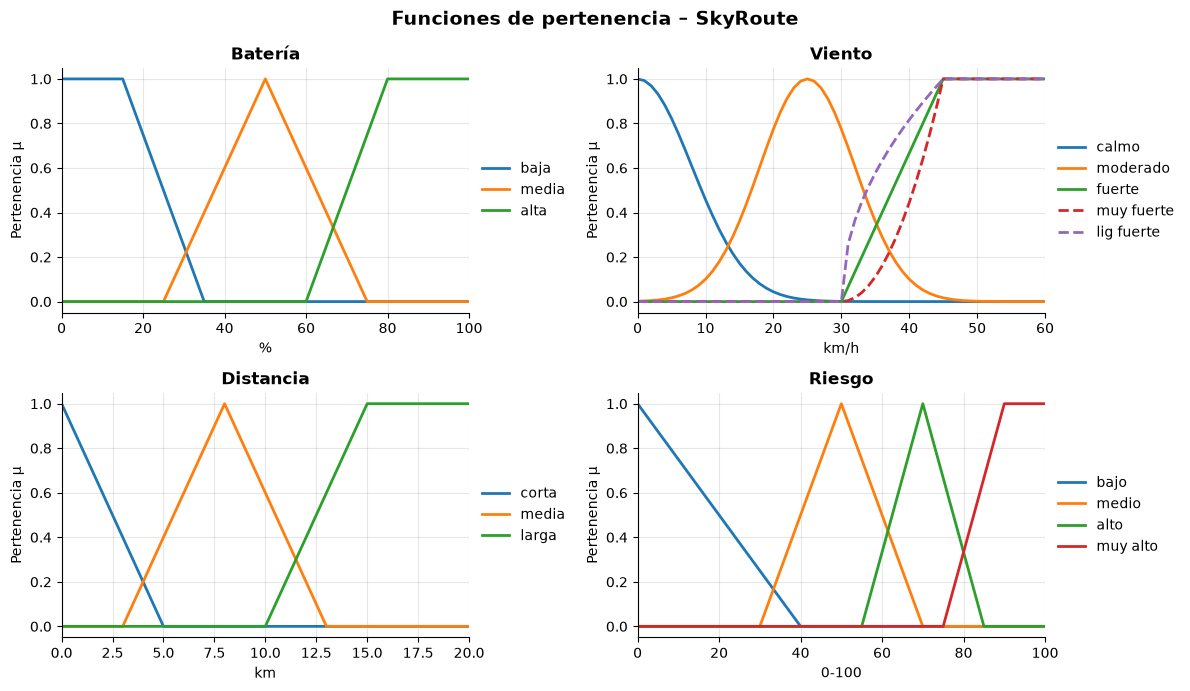

In [6]:
import matplotlib.pyplot as plt
from difuso import bateria, viento, distancia, riesgo

variables = [
    (bateria,   "Batería",   "%"),
    (viento,    "Viento",    "km/h"),
    (distancia, "Distancia", "km"),
    (riesgo,    "Riesgo",    "0-100"),
]
modificadores = {"muy_fuerte", "lig_fuerte"}   # se dibujan punteados

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (var, titulo, unidad) in zip(axes.flat, variables):
    for nombre, termino in var.terms.items():
        estilo = "--" if nombre in modificadores else "-"
        ax.plot(var.universe, termino.mf, estilo, lw=2, label=nombre.replace("_", " "))
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel(unidad)
    ax.set_ylabel("Pertenencia μ")
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(var.universe[0], var.universe[-1])
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

fig.suptitle("Funciones de pertenencia – SkyRoute", fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

In [7]:
import re
import pandas as pd
from difuso import reglas

def bonito(texto):
    texto = re.sub(r"NOT-(\w+)\[(\w+)\]", r"\1 NO es \2", texto)   # NOT-bateria[baja] -> bateria NO es baja
    texto = re.sub(r"(\w+)\[(\w+)\]", r"\1 es \2", texto)          # viento[calmo]    -> viento es calmo
    texto = texto.replace("_", " ").replace(" AND ", " Y ").replace(" OR ", " O ")
    if " O " not in texto:                                        # si todo es Y, los paréntesis sobran
        texto = texto.replace("(", "").replace(")", "")
    return texto

tabla = pd.DataFrame({
    "Regla": [f"R{i}" for i in range(1, len(reglas) + 1)],
    "SI": [bonito(str(r.antecedent)) for r in reglas],
    "ENTONCES riesgo es": [r.consequent[0].term.label.replace("_", " ") for r in reglas],
})

colores = {"bajo": "#c8e6c9", "medio": "#fff59d", "alto": "#ffcc80", "muy alto": "#ef9a9a"}

(tabla.style
    .hide(axis="index")
    .map(lambda v: f"background-color: {colores[v]}; color: black; font-weight: bold",
         subset=["ENTONCES riesgo es"])
    .set_properties(**{"text-align": "left", "padding": "4px 12px"})
    .set_table_styles([{"selector": "th", "props": "text-align: left; padding: 4px 12px"}]))

Regla,SI,ENTONCES riesgo es
R1,bateria es alta Y viento es calmo Y distancia es corta,bajo
R2,bateria es baja O viento es muy fuerte,alto
R3,bateria es media Y distancia es media,medio
R4,bateria NO es baja Y viento es moderado,medio
R5,distancia es larga Y bateria es media,alto
R6,bateria es alta Y distancia es larga Y viento NO es fuerte,medio
R7,viento es lig fuerte Y bateria es alta,alto
R8,bateria es alta Y viento es moderado Y distancia es corta,bajo
R9,bateria es media Y viento es calmo Y distancia es corta,bajo
R10,bateria es alta Y viento es calmo Y distancia es media,bajo


## Justificación del método de defuzzificación
Para elegir el método de defuzzificación se compararon centroide, bisector y media de máximos en un escenario de viento creciente (batería 50 %, distancia 8 km). La media de máximos resultó inadecuada por dos razones:
1. Es insensible, porque mantuvo el riesgo en 50 entre 0 y 44.5 km/h e ignoró la contribución de las reglas de viento fuerte.
2. Es inestable, porque un cambio de 0.5 km/h elevó el riesgo de 50 a 89.6, lo que habría pasado de asignar la misión a abortarla.

Se eligió el centroide porque integra el aporte de todas las reglas activadas según su fuerza y produce cambios graduales y proporcionales a las entradas, algo esencial en decisiones de seguridad de vuelo.

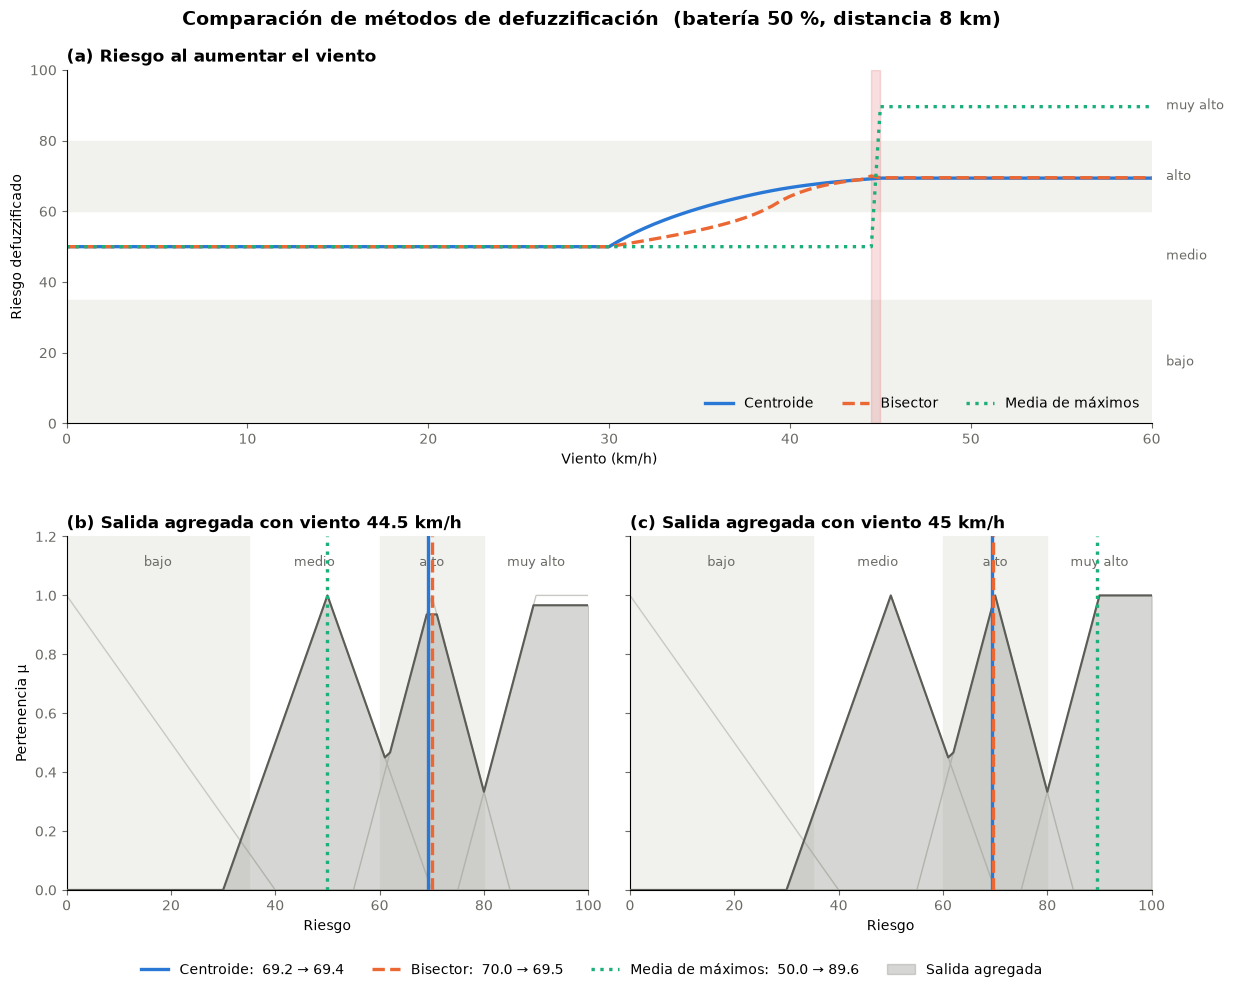

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from skfuzzy.control.controlsystem import CrispValueCalculator
from difuso import sistema, riesgo

BATERIA, DISTANCIA = 50, 8                 # escenario fijo
V_ANTES, V_DESPUES = 44.5, 45.0            # donde salta la media de máximos
METODOS = [('centroid', 'Centroide',        '#2a78d6', '-'),
           ('bisector', 'Bisector',         '#eb6834', '--'),
           ('mom',      'Media de máximos', '#1baf7a', ':')]
FRANJAS = [(0, 35, 'bajo'), (35, 60, 'medio'), (60, 80, 'alto'), (80, 100, 'muy alto')]
GRIS = '#6b6b66'

def salida_agregada(viento):
    sim = ctrl.ControlSystemSimulation(sistema)
    sim.input['bateria'], sim.input['viento'], sim.input['distancia'] = BATERIA, viento, DISTANCIA
    sim.compute()
    universo, agregada, _ = CrispValueCalculator(riesgo, sim).find_memberships()
    return universo, agregada

def defuzzificar(viento):
    u, a = salida_agregada(viento)
    return {m: fuzz.defuzz(u, a, m) for m, *_ in METODOS}

def limpiar(ax):
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(colors=GRIS)

# --- Datos del barrido de viento ---
vientos = np.arange(0, 60.5, 0.5)
barrido = [defuzzificar(v) for v in vientos]

# --- Figura: barrido arriba, dos salidas agregadas abajo ---
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.32, wspace=0.08)
ax_top = fig.add_subplot(gs[0, :])
ax_a = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[1, 1], sharey=ax_a)

# (a) Riesgo vs viento
for i, (ini, fin, nombre) in enumerate(FRANJAS):
    if i % 2 == 0:
        ax_top.axhspan(ini, fin, color='#f1f1ee', zorder=0)
    ax_top.text(60.8, (ini + fin) / 2, nombre, va='center', fontsize=9, color=GRIS)
for m, nombre, color, estilo in METODOS:
    ax_top.plot(vientos, [r[m] for r in barrido], color=color, ls=estilo, lw=2.4, label=nombre)
ax_top.axvspan(V_ANTES, V_DESPUES, color='#d62728', alpha=0.15, zorder=0)
mom_a, mom_b = defuzzificar(V_ANTES)['mom'], defuzzificar(V_DESPUES)['mom']
ax_top.set(xlim=(0, 60), ylim=(0, 100), xlabel='Viento (km/h)', ylabel='Riesgo defuzzificado')
ax_top.set_title('(a) Riesgo al aumentar el viento', loc='left', fontweight='bold')
ax_top.legend(loc='lower right', frameon=False, ncol=3)
limpiar(ax_top)

# (b) y (c) Salida agregada antes y después del salto
def dibujar_salida(ax, viento, titulo):
    u, a = salida_agregada(viento)
    for i, (ini, fin, nombre) in enumerate(FRANJAS):
        if i % 2 == 0:
            ax.axvspan(ini, fin, color='#f1f1ee', zorder=0)
        ax.text((ini + fin) / 2, 1.1, nombre, ha='center', fontsize=9, color=GRIS)
    for termino in riesgo.terms.values():
        ax.plot(riesgo.universe, termino.mf, color='#c9c9c3', lw=1, zorder=1)
    ax.fill_between(u, 0, a, color='#8a8a84', alpha=0.35, zorder=2)
    ax.plot(u, a, color='#5c5c57', lw=1.5, zorder=3)
    for m, nombre, color, estilo in METODOS:
        valor = fuzz.defuzz(u, a, m)
        ax.axvline(valor, color=color, ls=estilo, lw=2.4, zorder=4)
    ax.set(xlim=(0, 100), ylim=(0, 1.2), xlabel='Riesgo')
    ax.set_title(titulo, loc='left', fontweight='bold')
    limpiar(ax)

dibujar_salida(ax_a, V_ANTES,   f'(b) Salida agregada con viento {V_ANTES} km/h')
dibujar_salida(ax_b, V_DESPUES, f'(c) Salida agregada con viento {V_DESPUES:g} km/h')
ax_a.set_ylabel('Pertenencia μ')
plt.setp(ax_b.get_yticklabels(), visible=False)

# Leyenda común para (b) y (c) con los valores de cada método
va, vb = defuzzificar(V_ANTES), defuzzificar(V_DESPUES)
handles = [plt.Line2D([], [], color=c, ls=e, lw=2.4,
                      label=f'{n}:  {va[m]:.1f} → {vb[m]:.1f}') for m, n, c, e in METODOS]
handles.append(plt.Rectangle((0, 0), 1, 1, color='#8a8a84', alpha=0.35, label='Salida agregada'))
fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False, fontsize=10,
           bbox_to_anchor=(0.5, 0.0))

fig.suptitle(f'Comparación de métodos de defuzzificación  (batería {BATERIA} %, distancia {DISTANCIA} km)',
             fontsize=14, fontweight='bold', y=0.98)
fig.subplots_adjust(bottom=0.1, top=0.92)
plt.show()

# Ejecución

In [9]:
%run main.py --traza


1. ONTOLOGÍA Y RAZONAMIENTO (RDFLib + OWL-RL)
Tripletas escritas en ontologia.ttl: 372
Tripletas después de razonar:      818
Hechos nuevos sobre individuos:    92

2. TRADUCTOR ONTOLOGÍA -> SISTEMA EXPERTO
Hechos generados desde el grafo: 460 (99 provienen de inferencias)
   Atributo         102
   Clase            20
   Cliente          4
   Clima            4
   Dron             12
   EstacionCarga    4
   Mision           8
   Operador         4
   Paquete          14
   Pertenencia      136
   Propiedad        21
   Relacion         96
   SubClaseDe       21
   SubPropiedadDe   2
   Zona             12

3. LÓGICA DIFUSA: RIESGO DE CADA PAREJA DRON-MISIÓN
Clima más reciente: C04 (despejado, viento 15.0 km/h)
Evaluaciones: 64  ->  bajo: 15, medio: 37, alto: 12, muy_alto: 0

4. SISTEMA EXPERTO (Experta)
Traza de reglas disparadas (orden de ejecución):
  FIRE   1  salience=100  especificidad= 5  prohibir_zona_restringida          f-452(Z04), f-425(M03), f-365
  FIRE   2  salience=100